
# Lab 7: Hyperparameter Tuning and Model Selection using Cross-Validation

**Dataset:** Olist Brazilian E-Commerce Dataset  
**Primary Model:** Logistic Regression  
**Target:** `is_late_delivery`

This notebook follows the uploaded lab manual: safe feature selection, stratified train-test split, preprocessing pipeline, GridSearchCV with L1/L2 regularization and multiple `C` values, final test evaluation, coefficient comparison, and the optional recall-focused search.


## 1. Import Required Libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load the Dataset

The lab manual specifies the processed file path below.

In [2]:

data_path = "../data/processed/olist_orders_feature_engineered.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (99441, 23)


,total_price,total_freight,total_items,unique_products,unique_sellers,order_month,order_day_of_week,order_hour,average_item_price,freight_ratio,...,is_business_hour,is_year_end,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price,is_late_delivery
0,29.99,8.72,1.0,1.0,1.0,10,0,10,29.99,0.290764,...,1,0,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99,0
1,118.70,22.76,1.0,1.0,1.0,7,1,20,118.70,0.191744,...,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70,0
2,159.90,19.22,1.0,1.0,1.0,8,2,8,159.90,0.120200,...,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90,0
3,45.00,27.20,1.0,1.0,1.0,11,5,19,45.00,0.604444,...,0,1,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00,0
4,19.90,8.72,1.0,1.0,1.0,2,1,21,19.90,0.438191,...,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90,0


In [3]:

# Basic dataset inspection
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))


Columns:
['total_price', 'total_freight', 'total_items', 'unique_products', 'unique_sellers', 'order_month', 'order_day_of_week', 'order_hour', 'average_item_price', 'freight_ratio', 'items_per_seller', 'seller_diversity', 'is_weekend', 'is_business_hour', 'is_year_end', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'log_total_price', 'log_total_freight', 'items_x_price', 'is_late_delivery']

Data types:


total_price           float64
total_freight         float64
total_items           float64
unique_products       float64
unique_sellers        float64
order_month             int64
order_day_of_week       int64
order_hour              int64
average_item_price    float64
freight_ratio         float64
items_per_seller      float64
seller_diversity      float64
is_weekend              int64
is_business_hour        int64
is_year_end             int64
month_sin             float64
month_cos             float64
hour_sin              float64
hour_cos              float64
log_total_price       float64
log_total_freight     float64
items_x_price         float64
is_late_delivery        int64
dtype: object


Missing values:


total_price           775
average_item_price    775
items_x_price         775
log_total_freight     775
log_total_price       775
total_freight         775
items_per_seller      775
freight_ratio         775
seller_diversity      775
unique_sellers        775
unique_products       775
total_items           775
order_hour              0
order_day_of_week       0
order_month             0
is_weekend              0
is_business_hour        0
is_year_end             0
month_sin               0
month_cos               0
dtype: int64

## 3. Inspect the Target

In [4]:

target = "is_late_delivery"

print("Target value counts:")
display(df[target].value_counts())

print("\nTarget proportions:")
display(df[target].value_counts(normalize=True))

print(f"\nPercentage of late orders: {df[target].mean() * 100:.2f}%")


Target value counts:


is_late_delivery
0    92906
1     6535
Name: count, dtype: int64


Target proportions:


is_late_delivery
0    0.934283
1    0.065717
Name: proportion, dtype: float64


Percentage of late orders: 6.57%



## 4. Select Safe Features and Target

The lab manual uses the following engineered features and excludes leakage columns such as actual delivery information, review-related information, and identifiers.


In [5]:

features = [
    "total_price",
    "total_freight",
    "total_items",
    "unique_products",
    "unique_sellers",
    "average_item_price",
    "freight_ratio",
    "items_per_seller",
    "seller_diversity",
    "is_weekend",
    "is_business_hour",
    "month_sin",
    "month_cos",
    "hour_sin",
    "hour_cos",
    "log_total_price",
    "log_total_freight",
    "items_x_price"
]

target = "is_late_delivery"

# Check that all required columns exist before selecting them.
missing_features = [col for col in features + [target] if col not in df.columns]

if missing_features:
    raise KeyError(
        "The following required columns are missing from the dataset: "
        + ", ".join(missing_features)
    )

X = df[features].copy()
y = df[target].copy()

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())


Number of features: 18
X shape: (99441, 18)
y shape: (99441,)


,total_price,total_freight,total_items,unique_products,unique_sellers,average_item_price,freight_ratio,items_per_seller,seller_diversity,is_weekend,is_business_hour,month_sin,month_cos,hour_sin,hour_cos,log_total_price,log_total_freight,items_x_price
0,29.99,8.72,1.0,1.0,1.0,29.99,0.290764,1.0,1.0,0,1,-0.866025,0.500000,0.500000,-0.866025,3.433665,2.274186,29.99
1,118.70,22.76,1.0,1.0,1.0,118.70,0.191744,1.0,1.0,0,0,-0.500000,-0.866025,-0.866025,0.500000,4.784989,3.168003,118.70
2,159.90,19.22,1.0,1.0,1.0,159.90,0.120200,1.0,1.0,0,0,-0.866025,-0.500000,0.866025,-0.500000,5.080783,3.006672,159.90
3,45.00,27.20,1.0,1.0,1.0,45.00,0.604444,1.0,1.0,1,0,-0.500000,0.866025,-0.965926,0.258819,3.828641,3.339322,45.00
4,19.90,8.72,1.0,1.0,1.0,19.90,0.438191,1.0,1.0,0,0,0.866025,0.500000,-0.707107,0.707107,3.039749,2.274186,19.90


## 5. Train-Test Split

The test set remains untouched until final evaluation.

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True))


X_train: (79552, 18)
X_test : (19889, 18)
y_train: (79552,)
y_test : (19889,)

Training target distribution:


is_late_delivery
0    0.934282
1    0.065718
Name: proportion, dtype: float64


Test target distribution:


is_late_delivery
0    0.934285
1    0.065715
Name: proportion, dtype: float64


## 6. Build the Preprocessing Pipeline

The pipeline uses:

1. Median imputation
2. Standard scaling
3. Logistic Regression

Putting preprocessing inside the pipeline prevents validation/test information from leaking into preprocessing during cross-validation.


In [7]:

pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                solver="liblinear",
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

print(pipeline)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])


## 7. Define the Hyperparameter Grid

In [8]:

param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.01, 0.1, 1, 10, 100]
}

print("Hyperparameter grid:")
display(param_grid)


Hyperparameter grid:


{'model__penalty': ['l1', 'l2'], 'model__C': [0.01, 0.1, 1, 10, 100]}

## 8. Configure Stratified Cross-Validation

In [9]:

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation configured.")


5-fold Stratified Cross-Validation configured.


## 9. Run Grid Search using F1 Score

In [10]:

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Grid search completed.")
print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(grid_search.best_score_)


Grid search completed.

Best parameters:
{'model__C': 0.1, 'model__penalty': 'l1'}

Best cross-validation F1:
0.17637158744746823


## 10. Inspect All Cross-Validation Results

In [11]:

results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "param_model__penalty",
    "param_model__C",
    "mean_train_score",
    "std_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

results_table = (
    results[result_columns]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

display(results_table)


,param_model__penalty,param_model__C,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,l1,0.10,0.176834,0.000501,0.176372,0.001823,1
1,l2,10.00,0.176850,0.000617,0.176302,0.001762,2
2,l1,100.00,0.176849,0.000618,0.176302,0.001762,2
3,l2,100.00,0.176849,0.000619,0.176297,0.001762,4
4,l2,1.00,0.176844,0.000610,0.176293,0.001774,5
5,l1,10.00,0.176849,0.000612,0.176288,0.001753,6
6,l2,0.10,0.176847,0.000579,0.176275,0.001751,7
7,l1,1.00,0.176853,0.000585,0.176271,0.001777,8
8,l2,0.01,0.176832,0.000582,0.176145,0.001738,9
9,l1,0.01,0.176498,0.000507,0.176009,0.002250,10


In [12]:

# Rename columns for a cleaner final results table
results_table_clean = results_table.rename(
    columns={
        "param_model__penalty": "Penalty",
        "param_model__C": "C",
        "mean_train_score": "Mean Train F1",
        "std_train_score": "Std Train F1",
        "mean_test_score": "Mean CV F1",
        "std_test_score": "Std CV F1",
        "rank_test_score": "CV Rank"
    }
)

display(results_table_clean)


,Penalty,C,Mean Train F1,Std Train F1,Mean CV F1,Std CV F1,CV Rank
0,l1,0.10,0.176834,0.000501,0.176372,0.001823,1
1,l2,10.00,0.176850,0.000617,0.176302,0.001762,2
2,l1,100.00,0.176849,0.000618,0.176302,0.001762,2
3,l2,100.00,0.176849,0.000619,0.176297,0.001762,4
4,l2,1.00,0.176844,0.000610,0.176293,0.001774,5
5,l1,10.00,0.176849,0.000612,0.176288,0.001753,6
6,l2,0.10,0.176847,0.000579,0.176275,0.001751,7
7,l1,1.00,0.176853,0.000585,0.176271,0.001777,8
8,l2,0.01,0.176832,0.000582,0.176145,0.001738,9
9,l1,0.01,0.176498,0.000507,0.176009,0.002250,10



### Questions

- Which penalty and `C` produced the highest mean CV F1?
- Which configuration had the lowest variation (`Std CV F1`)?


In [13]:

best_cv_row = results_table_clean.iloc[0]

lowest_variation_row = results_table_clean.loc[
    results_table_clean["Std CV F1"].idxmin()
]

print("Highest mean CV F1 configuration:")
display(best_cv_row.to_frame().T)

print("\nLowest variation configuration:")
display(lowest_variation_row.to_frame().T)


Highest mean CV F1 configuration:


,Penalty,C,Mean Train F1,Std Train F1,Mean CV F1,Std CV F1,CV Rank
0,l1,0.1,0.176834,0.000501,0.176372,0.001823,1



Lowest variation configuration:


,Penalty,C,Mean Train F1,Std Train F1,Mean CV F1,Std CV F1,CV Rank
8,l2,0.01,0.176832,0.000582,0.176145,0.001738,9


## 11. Final Test Evaluation

In [14]:

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, zero_division=0)
test_recall = recall_score(y_test, y_pred, zero_division=0)
test_f1 = f1_score(y_test, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")


Accuracy : 0.5824
Precision: 0.1036
Recall   : 0.7001
F1 Score : 0.1805
ROC-AUC  : 0.6606


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.57      0.72     18582
           1       0.10      0.70      0.18      1307

    accuracy                           0.58     19889
   macro avg       0.53      0.64      0.45     19889
weighted avg       0.91      0.58      0.68     19889

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,10668,7914
Actual 1,392,915


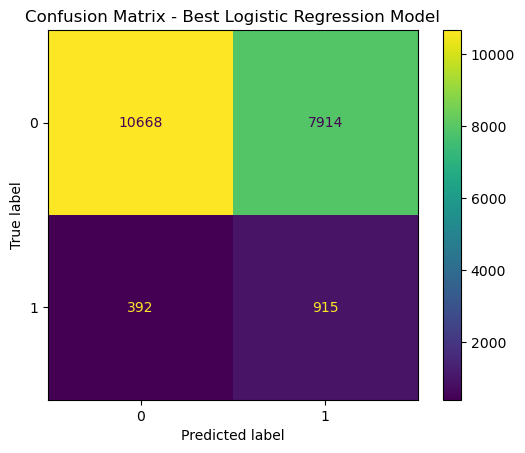

In [20]:

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Best Logistic Regression Model")
plt.show()


## 12. Compare L1 and L2 Coefficients

In [16]:

l1_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                penalty="l1",
                solver="liblinear",
                C=1.0,
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

l2_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                C=1.0,
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

l1_pipeline.fit(X_train, y_train)
l2_pipeline.fit(X_train, y_train)

l1_coefficients = l1_pipeline.named_steps["model"].coef_[0]
l2_coefficients = l2_pipeline.named_steps["model"].coef_[0]

coefficient_comparison = pd.DataFrame({
    "Feature": features,
    "L1": l1_coefficients,
    "L2": l2_coefficients
})

display(coefficient_comparison)


,Feature,L1,L2
0,total_price,-0.145991,-0.159185
1,total_freight,-0.044439,-0.044412
2,total_items,-0.512910,-0.585378
3,unique_products,-0.040063,-0.040043
4,unique_sellers,-0.112990,-0.095148
5,average_item_price,0.113574,0.123324
6,freight_ratio,0.064322,0.064613
7,items_per_seller,0.478206,0.544919
8,seller_diversity,0.105479,0.103650
9,is_weekend,-0.043067,-0.043119


In [17]:

print("L1 zero coefficients:", np.sum(l1_coefficients == 0))
print("L2 zero coefficients:", np.sum(l2_coefficients == 0))


L1 zero coefficients: 0
L2 zero coefficients: 0



### Interpretation

- L1 may set some coefficients exactly to zero, giving it a feature-selection effect.
- L2 generally keeps coefficients non-zero while shrinking them toward zero.
- Coefficients are compared after scaling, as required by the lab manual.


## 13. Study the Effect of `C` for L1

In [21]:

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
zero_counts = []

for C in C_values:
    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=1000,
                    class_weight="balanced"
                )
            )
        ]
    )

    model.fit(X_train, y_train)

    coefficients = model.named_steps["model"].coef_[0]
    zero_counts.append(np.sum(coefficients == 0))

zero_table = pd.DataFrame({
    "C": C_values,
    "Zero Coefficients": zero_counts
})

display(zero_table)


,C,Zero Coefficients
0,0.001,12
1,0.010,4
2,0.100,2
3,1.000,0
4,10.000,0
5,100.000,0


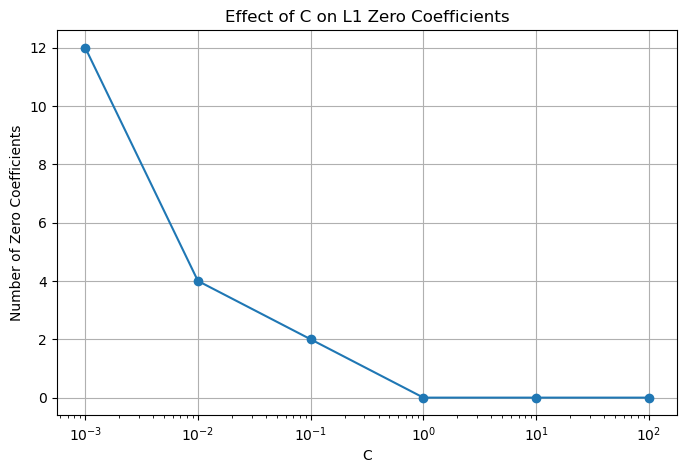

In [22]:

plt.figure(figsize=(8, 5))
plt.plot(zero_table["C"], zero_table["Zero Coefficients"], marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Number of Zero Coefficients")
plt.title("Effect of C on L1 Zero Coefficients")
plt.grid(True)
plt.show()



## 14. Optional Extension: Optimize Recall

The lab manual also provides a recall-focused GridSearchCV. This is useful when missing late deliveries is more costly than generating additional alerts.


In [ ]:

recall_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="recall",
    n_jobs=-1
)

recall_search.fit(X_train, y_train)

print("Best parameters for recall:")
print(recall_search.best_params_)

print("\nBest cross-validation recall:")
print(recall_search.best_score_)


## 15. Final Results Table

In [ ]:

# Build a compact submission-style table.
final_results = results.copy()

final_results["Penalty"] = final_results["param_model__penalty"]
final_results["C"] = final_results["param_model__C"]

final_results["Test Accuracy"] = np.nan
final_results["Test Precision"] = np.nan
final_results["Test Recall"] = np.nan
final_results["Test F1"] = np.nan

# Evaluate every grid configuration on the untouched test set.
for i, row in final_results.iterrows():
    penalty = row["param_model__penalty"]
    C = row["param_model__C"]

    model = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    penalty=penalty,
                    solver="liblinear",
                    C=float(C),
                    max_iter=1000,
                    class_weight="balanced"
                )
            )
        ]
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    final_results.loc[i, "Test Accuracy"] = accuracy_score(y_test, pred)
    final_results.loc[i, "Test Precision"] = precision_score(
        y_test, pred, zero_division=0
    )
    final_results.loc[i, "Test Recall"] = recall_score(
        y_test, pred, zero_division=0
    )
    final_results.loc[i, "Test F1"] = f1_score(
        y_test, pred, zero_division=0
    )

submission_table = final_results[
    [
        "Penalty",
        "C",
        "mean_test_score",
        "std_test_score",
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1"
    ]
].rename(
    columns={
        "mean_test_score": "Mean CV F1",
        "std_test_score": "Std CV F1"
    }
)

submission_table = submission_table.sort_values(
    ["Mean CV F1", "Std CV F1"],
    ascending=[False, True]
).reset_index(drop=True)

display(submission_table)



## 16. Short Business Recommendation

Use the cross-validation results to select a configuration rather than tuning on the test set. The final test set should only provide the final estimate of performance on unseen data.

For late-delivery prediction, F1 balances precision and recall. If the business cost of missing a late delivery is especially high, the recall-focused GridSearchCV result should also be considered alongside the other operational requirements.



## 17. Lab Questions / Reflection

1. What is the difference between a parameter and a hyperparameter?
2. Why is `C` the inverse of regularization strength?
3. Why can L1 perform feature selection?
4. Why does L2 generally retain more features?
5. Why must scaling be inside the pipeline?
6. Why should the test set remain untouched?
7. What does a large train-validation gap indicate?
8. Why is stratified cross-validation appropriate here?
9. Why might recall be more important than accuracy?
10. Which configuration would you select based on the documented CV and test results, and why?
